In [92]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv('C:\\Users\\Yoog\\Documents\\Adrián Fdez López\\Profesional\\Curso Data Scientist\\Data\\laptops_Dataset.csv')
df.head()

,Brand:,Product name,Processor,Video graphics,Video graphics Memorey,RAM,Hard drive,Display,Display Resolution,Display Refresh Rate,Operating System,Keyboard,Battery,Webcam,Connections,Dimensions,Weight,Colors,Warranty,Price,Processor Generation,Processor Details,Product number,Power supply type,Laptop Color,Finger Print,SUPPORT SSD M2,Pointing device,Optical drive,Series :
0,MSI,Titan 18 HX Dragon Edition Norse Myth A2XWJG,Intel Core Ultra 9 285HX,Nvidia GeForce RTX 5090 24GB,24GB GDDR7,96GB DDR5 6400MHz 48GB*2,"6TB, 2TB NVMe PCIe Gen5x4 SSD w/o DRAM + 2TB N...","18"" 16:10 UHD+ (3840x2400), MiniLED, 120Hz, 10...",3840x2400,120 Hz,Windows® 11 Home,Cherry Mechanical Per-Key RGB Gaming Keyboard ...,4-Cell 99 Battery (Whr),IR FHD type (30fps@1080p) with HDR 3D Noise Re...,2x Thunderbolt™ 5 (DisplayPort™/ Power Deliver...,404 x 307.5 x 24-32.05 mm,3.6 kg,Core Black,2 Year,320000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,MSI,Katana 15 HX 14XWGK,Intel Core i9-14900HX,Nvidia GeForce RTX 5070 8GB,8GB GDDR7,16GB DDR5 8GB*2,1TB NVMe PCIe SSD Gen4x4,"15.6"" QHD (2560*1440), 165Hz DCI-P3 100% typical",2560*1440,165 HZ,Windows® 11 Home,4-Zone RGB Gaming Keyboard,"4 cell, 75Whr",HD Webcam (720p @ 30fps),1x USB Type-C (USB 3.2 Gen2 / DisplayPort / Po...,359 x 262 x 25.5 mm,2.4 kg,Black,2 Year,79999,14th generation,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Acer,NITRO V15-ANV15-51-51H9,Intel Core I5-13420H,Nvidia GeForce RTX 4050 6GB,6GB GDDR6,8 GB DDR5-SDRAM,512 GB SSD,15.6'' Inch FHD IPS LED backlight aspect ratio...,1920x1080,144 Hz,Windows® 11 Home,NaN,57 Wh,NaN,USB 3.2 Gen 1 (3.1 Gen 1) Type-A ports quantit...,NaN,NaN,Black,1 Year,39999,13th generation,"8C (4P + 4E) / 12T, P-core 2.1 / 4.6GHz, E-cor...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Dell,Alienware 16 Aurora AC16250,Intel Core 7 240H,NVIDIA(R) GeForce RTX(TM) 5050,8 GB GDDR7,"16GB, 2x8GB, DDR5, 5600 MT/s ( 5200 MT/s with ...",512GB M.2 PCIe NVMe SSD,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",2560 x 1600,120 Hz,Windows 11 Home,NaN,"6-Cell Battery, 96 Whr (Integr ated)",NaN,2 USB 3.2 Gen 1 (5 Gbps) ports 1 USB 3.2 Gen 2...,356.98 x 265.43 x 15.20 mm,2.49 kg,NaN,1 Year,57999,NaN,"240H (24MB cache, 1 0 cores, 1.80 to 5.20 GHz ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Dell,Alienware 16 Aurora AC16250,Intel Core 9 270H,Nvidia GeForce RTX 5060 8GB,8GB GDDR7,"16GB, 2x8GB, DDR5, 5600 MT/s",1TB M.2 PCIe NVMe SSD,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",2560 x 1600,120 Hz,DOS,Alienware White Backlit Keyboard,"6-Cell Battery, 96 Whr (Integrated)","720p at 30 fps HD camera, Dual-array microphones",2 USB Type-A 3.2 Gen 1 Port 1 Type-C® Port (US...,356.98 x 265.43 x 22.70 mm,2.49 kg,NaN,1 Year,89999,NaN,"24MB cache, 14 cores, 2.00 to 5.80 GHz P-Core",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Limpieza e Ingeniería de Datos

In [93]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1033 entries, 0 to 1032
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Brand:                  977 non-null    str  
 1   Product name            1033 non-null   str  
 2   Processor               1033 non-null   str  
 3   Video graphics          1032 non-null   str  
 4   Video graphics Memorey  680 non-null    str  
 5   RAM                     1033 non-null   str  
 6   Hard drive              1033 non-null   str  
 7   Display                 1029 non-null   str  
 8   Display Resolution      1013 non-null   str  
 9   Display Refresh Rate    680 non-null    str  
 10  Operating System        1026 non-null   str  
 11  Keyboard                932 non-null    str  
 12  Battery                 1003 non-null   str  
 13  Webcam                  892 non-null    str  
 14  Connections             1009 non-null   str  
 15  Dimensions              986 non-

In [94]:
df.shape

(1033, 30)

Se observan variables como ``Product name``, ``Keyboard``, ``Colors``, ... que no aportan ningún poder predictivo así que iremos eliminándolas para reducir el ruido de nuestro modelo desde un principio y trabajar con una menor cantidad de variables y datos.

In [95]:
df = df.drop(columns = ['Product name', 'Battery', 'Dimensions', 'Colors', 'Keyboard', 'Connections', 'Processor Details', 'Product number', 'Power supply type', 'Laptop Color', 'SUPPORT SSD M2', 'Pointing device', 'Optical drive', 'Series :'])

df.shape

(1033, 16)

In [96]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1033 entries, 0 to 1032
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   Brand:                  977 non-null    str  
 1   Processor               1033 non-null   str  
 2   Video graphics          1032 non-null   str  
 3   Video graphics Memorey  680 non-null    str  
 4   RAM                     1033 non-null   str  
 5   Hard drive              1033 non-null   str  
 6   Display                 1029 non-null   str  
 7   Display Resolution      1013 non-null   str  
 8   Display Refresh Rate    680 non-null    str  
 9   Operating System        1026 non-null   str  
 10  Webcam                  892 non-null    str  
 11  Weight                  993 non-null    str  
 12  Warranty                1033 non-null   str  
 13  Price                   1033 non-null   int64
 14  Processor Generation    696 non-null    str  
 15  Finger Print            64 non-n

In [97]:
df.isnull().sum()

Brand:                     56
Processor                   0
Video graphics              1
Video graphics Memorey    353
RAM                         0
Hard drive                  0
Display                     4
Display Resolution         20
Display Refresh Rate      353
Operating System            7
Webcam                    141
Weight                     40
Warranty                    0
Price                       0
Processor Generation      337
Finger Print              969
dtype: int64

In [98]:
df.head()

,Brand:,Processor,Video graphics,Video graphics Memorey,RAM,Hard drive,Display,Display Resolution,Display Refresh Rate,Operating System,Webcam,Weight,Warranty,Price,Processor Generation,Finger Print
0,MSI,Intel Core Ultra 9 285HX,Nvidia GeForce RTX 5090 24GB,24GB GDDR7,96GB DDR5 6400MHz 48GB*2,"6TB, 2TB NVMe PCIe Gen5x4 SSD w/o DRAM + 2TB N...","18"" 16:10 UHD+ (3840x2400), MiniLED, 120Hz, 10...",3840x2400,120 Hz,Windows® 11 Home,IR FHD type (30fps@1080p) with HDR 3D Noise Re...,3.6 kg,2 Year,320000,NaN,NaN
1,MSI,Intel Core i9-14900HX,Nvidia GeForce RTX 5070 8GB,8GB GDDR7,16GB DDR5 8GB*2,1TB NVMe PCIe SSD Gen4x4,"15.6"" QHD (2560*1440), 165Hz DCI-P3 100% typical",2560*1440,165 HZ,Windows® 11 Home,HD Webcam (720p @ 30fps),2.4 kg,2 Year,79999,14th generation,NaN
2,Acer,Intel Core I5-13420H,Nvidia GeForce RTX 4050 6GB,6GB GDDR6,8 GB DDR5-SDRAM,512 GB SSD,15.6'' Inch FHD IPS LED backlight aspect ratio...,1920x1080,144 Hz,Windows® 11 Home,NaN,NaN,1 Year,39999,13th generation,NaN
3,Dell,Intel Core 7 240H,NVIDIA(R) GeForce RTX(TM) 5050,8 GB GDDR7,"16GB, 2x8GB, DDR5, 5600 MT/s ( 5200 MT/s with ...",512GB M.2 PCIe NVMe SSD,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",2560 x 1600,120 Hz,Windows 11 Home,NaN,2.49 kg,1 Year,57999,NaN,NaN
4,Dell,Intel Core 9 270H,Nvidia GeForce RTX 5060 8GB,8GB GDDR7,"16GB, 2x8GB, DDR5, 5600 MT/s",1TB M.2 PCIe NVMe SSD,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",2560 x 1600,120 Hz,DOS,"720p at 30 fps HD camera, Dual-array microphones",2.49 kg,1 Year,89999,NaN,NaN


In [99]:
df = df.rename(columns={'Brand:': 'Brand'})

Observamos que tenemos un montón de variables numéricas que añaden prefijos/sufijos (kg, GB...) entonces usaremos la función ``str.extract`` para extraer los valores numéricos de estas variables

In [100]:
df['RAM_GB'] = df['RAM'].str.extract(r'(\d+)').astype(float)
df['Warranty_Years'] = df['Warranty'].str.extract(r'(\d+)').astype(float)
df['Refresh Rate'] = df['Display Refresh Rate'].str.extract(r'(\d+)').astype(float)
df['Processor_Generation'] = df['Processor Generation'].str.extract(r'(\d+)').astype(float)

df['Weight_kg'] = df['Weight'].str.extract(r'(\d+\.?\d*)').astype(float)
df['Screen_Size'] = df['Display'].str.extract(r'(\d+\.?\d*)').astype(float)

df['Video graphics Memory'] = df['Video graphics Memorey'].str.extract(r'(\d+)\s*GB').astype(float)

df[ ['RAM_GB', 'Warranty_Years', 'Refresh Rate', 'Processor_Generation', 'Weight_kg', 'Screen_Size', 'Video graphics Memory']].head()

,RAM_GB,Warranty_Years,Refresh Rate,Processor_Generation,Weight_kg,Screen_Size,Video graphics Memory
0,96.0,2.0,120.0,NaN,3.60,18.0,24.0
1,16.0,2.0,165.0,14.0,2.40,15.6,8.0
2,8.0,1.0,144.0,13.0,NaN,15.6,6.0
3,16.0,1.0,120.0,NaN,2.49,16.0,8.0
4,16.0,1.0,120.0,NaN,2.49,16.0,8.0


Vamos a pasar a normalizar el almacenamiento ``Hard drive`` pues no es lo mismo 1TB que 512GB. Pasemos todo a GB

In [101]:
df['Storage_GB'] = 0 #Creamos una columna nueva rellena de ceros 
#la cual nos servirá para ir guardando el almacenamiento correspondiente
#a cada uno de los portátiles

df.loc[df['Hard drive'].str.contains('TB', na = False), 'Storage_GB'] = df['Hard drive'].str.extract(r'(\d+)\s*TB').astype(float)[0]*1024
#Con 'loc.[]' accedemos a las posiciones que contiene TB
#devolviendo True si lo hace y False si no o si Nan
#y para las True modificamos 'Storage_GB' con el valor después del =
#extrayendo números ignorando espacios opciones y la 
#palabra literal TB convirtiéndolos a formato decimal
#con [0] extraemos la columna donde están esos formatos
#para poder hacer la transformación.

df.loc[~df['Hard drive'].str.contains('TB', na = False), 'Storage_GB'] = df['Hard drive'].str.extract(r'(\d+)\s*GB').astype(float)[0]
#Aquí buscamos los que NO contiene GB (con ~)

df[ ['Hard drive', 'Storage_GB'] ].head()

,Hard drive,Storage_GB
0,"6TB, 2TB NVMe PCIe Gen5x4 SSD w/o DRAM + 2TB N...",6144.0
1,1TB NVMe PCIe SSD Gen4x4,1024.0
2,512 GB SSD,512.0
3,512GB M.2 PCIe NVMe SSD,512.0
4,1TB M.2 PCIe NVMe SSD,1024.0


Vamos a tratar de aprovechar la variable ``Processor`` a través del modelo que pueda ser en función de si contiene un 9, 7, 5, 3. Es decir a partir de la gama de estos, siendo más informativo y fácil de modelar. 

In [102]:
df['Processor'].value_counts()

Processor
Intel Core I5-1135G7      41
Intel Core I7-12700H      32
Intel Core I7-1165G7      26
Intel Core I7-11800H      25
Intel Core i7-13700H      15
                          ..
Intel core i5-1135G7       1
INTEL CORE i5-1035G1       1
Intel® Core™ i5-10210U     1
AMD Ryzen 9-5980HS         1
AMD Ryzen™ 9-5900HS        1
Name: count, Length: 300, dtype: int64

In [103]:
df['CPU_Class'] = 'Other'
df.loc[df['Processor'].str.contains('9', case=False, na=False), 'CPU_Class'] = 'Gama Alta (i9)'
df.loc[df['Processor'].str.contains('i7', case=False, na=False), 'CPU_Class'] = 'Gama Media-Alta (i7)'
df.loc[df['Processor'].str.contains('i5', case=False, na=False), 'CPU_Class'] = 'Gama Media (i5)'
df.loc[df['Processor'].str.contains('3', case=False, na=False), 'CPU_Class'] = 'Gama Baja (i3)'

Vamos a tratar de agrupar también la variable ``Video graphics`` puesto que toma muchos valores y sabemos que 'Nvidia', 'AMD', 'Intel' son las más habituales así que consideraremos esta agrupación como un approach razonable.

In [104]:
df['Video graphics'].value_counts()

Video graphics
Intel UHD Graphics                  71
Intel Iris Xe Graphics              66
AMD Radeon Graphics                 29
NVIDIA® GeForce RTX™ 3050 4GB       27
NVIDIA® GeForce RTX™ 3050           26
                                    ..
NVIDIA® GeForce® MX570 2GB           1
NVIDIA® GeForce® MX450 2GB GDDR6     1
AMD Radeon™ 630                      1
NVIDIA GeForce MX230 2GB             1
NVIDIA® GeForce RTX™ 3060            1
Name: count, Length: 269, dtype: int64

In [105]:
df['GPU_Brand'] = 'Other'
df.loc[df['Video graphics'].str.contains('Nvidia', case=False, na=False), 'GPU_Brand'] = 'Nvidia'
df.loc[df['Video graphics'].str.contains('AMD', case=False, na=False), 'GPU_Brand'] = 'AMD'
df.loc[df['Video graphics'].str.contains('Intel', case=False, na=False), 'GPU_Brand'] = 'Intel'

Vamos a distinguir entre si es más potente o más modesta en función de si ``Video Graphics`` contiene '90|80', '70' o '60|50'.

<Axes: xlabel='count', ylabel='GPU_Tier'>

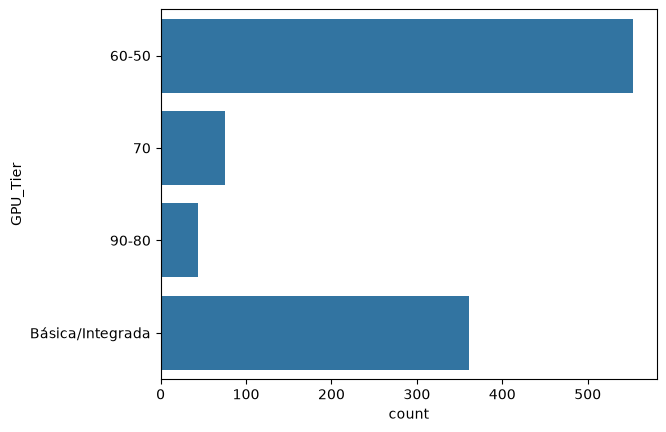

In [106]:
df['GPU_Tier'] = 'Básica/Integrada'

df.loc[df['Video graphics'].str.contains('90|80', na=False), 'GPU_Tier'] = '90-80'
df.loc[df['Video graphics'].str.contains('70', na=False), 'GPU_Tier'] = '70'
df.loc[df['Video graphics'].str.contains('60|50', na=False), 'GPU_Tier'] = '60-50'

sns.countplot(df['GPU_Tier'])

Tenemos las variables ``Display`` y ``Display Resolution`` las cuales aportan poco como están pero de las cuales podemos extraer información muy valiosa como el tamaño de la pantalla (pulgadas) y la resolución de la pantalla (megapíxeles).

In [107]:
df['Display Resolution'].head()

0      3840x2400
1      2560*1440
2      1920x1080
3    2560 x 1600
4    2560 x 1600
Name: Display Resolution, dtype: str

In [108]:
df['Display'].head()

0    18" 16:10 UHD+ (3840x2400), MiniLED, 120Hz, 10...
1     15.6" QHD (2560*1440), 165Hz DCI-P3 100% typical
2    15.6'' Inch FHD IPS LED backlight aspect ratio...
3    16" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...
4    16" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...
Name: Display, dtype: str

In [109]:
resolucion_split = df['Display Resolution'].str.extract(r'(\d+)\s*[xX*]\s*(\d+)')

df['Res_Width'] = resolucion_split[0].astype(float)
df['Res_Height'] = resolucion_split[1].astype(float)
#Creamos las columnas numéricas extrayendo anchura y altura

df['Total_Pixels'] = (df['Res_Width'] * df['Res_Height']) / 1000000
#Dividimos entre 1M para simplificar la variable

#Extraemos el número que acompaña a las pulgadas
df['Screen_Size'] = df['Display'].str.extract(r'(\d+[\.,]?\d*)').astype(float)
df['Screen_Size'].head()

0    18.0
1    15.6
2    15.6
3    16.0
4    16.0
Name: Screen_Size, dtype: float64

In [110]:
df['Total_Pixels'].head()

0    9.2160
1    3.6864
2    2.0736
3    4.0960
4    4.0960
Name: Total_Pixels, dtype: float64

Observemos ahora variables como ``Webcam`` o ``FIngerprint`` las cuales son muy interesantes pero no como me las dan definidas (incluyéndome el modelo de cada una). Simplemente nos interesa saber si tienen o no este tipo de tecnología así que podemos pasarlas a variables numéricas binarias en función de este criterio.

In [111]:
#Asumimos que si ambas variables presentan texto
#signfiica que tienen estos extras.

df['Has_Webcam'] = 0
df.loc[df['Webcam'].notna(), 'Has_Webcam'] = 1

df['Has_Fingerprint'] = 0
df.loc[df['Finger Print'].notna(), 'Has_Fingerprint'] = 1

df[['Has_Webcam', 'Has_Fingerprint']].head()

,Has_Webcam,Has_Fingerprint
0,1,0
1,1,0
2,0,0
3,0,0
4,1,0


Comprobemos como va quedando nuestro dataframe para ver que debemos modificar y que pasos vamos a seguir a continuación:

In [112]:
pd.set_option('display.max_columns', None)
df.head()

,Brand,Processor,Video graphics,Video graphics Memorey,RAM,Hard drive,Display,Display Resolution,Display Refresh Rate,Operating System,Webcam,Weight,Warranty,Price,Processor Generation,Finger Print,RAM_GB,Warranty_Years,Refresh Rate,Processor_Generation,Weight_kg,Screen_Size,Video graphics Memory,Storage_GB,CPU_Class,GPU_Brand,GPU_Tier,Res_Width,Res_Height,Total_Pixels,Has_Webcam,Has_Fingerprint
0,MSI,Intel Core Ultra 9 285HX,Nvidia GeForce RTX 5090 24GB,24GB GDDR7,96GB DDR5 6400MHz 48GB*2,"6TB, 2TB NVMe PCIe Gen5x4 SSD w/o DRAM + 2TB N...","18"" 16:10 UHD+ (3840x2400), MiniLED, 120Hz, 10...",3840x2400,120 Hz,Windows® 11 Home,IR FHD type (30fps@1080p) with HDR 3D Noise Re...,3.6 kg,2 Year,320000,NaN,NaN,96.0,2.0,120.0,NaN,3.60,18.0,24.0,6144.0,Gama Alta (i9),Nvidia,60-50,3840.0,2400.0,9.2160,1,0
1,MSI,Intel Core i9-14900HX,Nvidia GeForce RTX 5070 8GB,8GB GDDR7,16GB DDR5 8GB*2,1TB NVMe PCIe SSD Gen4x4,"15.6"" QHD (2560*1440), 165Hz DCI-P3 100% typical",2560*1440,165 HZ,Windows® 11 Home,HD Webcam (720p @ 30fps),2.4 kg,2 Year,79999,14th generation,NaN,16.0,2.0,165.0,14.0,2.40,15.6,8.0,1024.0,Gama Alta (i9),Nvidia,60-50,2560.0,1440.0,3.6864,1,0
2,Acer,Intel Core I5-13420H,Nvidia GeForce RTX 4050 6GB,6GB GDDR6,8 GB DDR5-SDRAM,512 GB SSD,15.6'' Inch FHD IPS LED backlight aspect ratio...,1920x1080,144 Hz,Windows® 11 Home,NaN,NaN,1 Year,39999,13th generation,NaN,8.0,1.0,144.0,13.0,NaN,15.6,6.0,512.0,Gama Baja (i3),Nvidia,60-50,1920.0,1080.0,2.0736,0,0
3,Dell,Intel Core 7 240H,NVIDIA(R) GeForce RTX(TM) 5050,8 GB GDDR7,"16GB, 2x8GB, DDR5, 5600 MT/s ( 5200 MT/s with ...",512GB M.2 PCIe NVMe SSD,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",2560 x 1600,120 Hz,Windows 11 Home,NaN,2.49 kg,1 Year,57999,NaN,NaN,16.0,1.0,120.0,NaN,2.49,16.0,8.0,512.0,Other,Nvidia,60-50,2560.0,1600.0,4.0960,0,0
4,Dell,Intel Core 9 270H,Nvidia GeForce RTX 5060 8GB,8GB GDDR7,"16GB, 2x8GB, DDR5, 5600 MT/s",1TB M.2 PCIe NVMe SSD,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",2560 x 1600,120 Hz,DOS,"720p at 30 fps HD camera, Dual-array microphones",2.49 kg,1 Year,89999,NaN,NaN,16.0,1.0,120.0,NaN,2.49,16.0,8.0,1024.0,Gama Alta (i9),Nvidia,60-50,2560.0,1600.0,4.0960,1,0


Hemos tocado casi todas las variables pero vemos que hay un montón de sistemas operativos diferentes, pero, como normal general solo hay 3 de interés: 'Other/Linux', 'Windows', 'maxOS' o 'No OS'.

In [113]:
df['Operating System'].value_counts()

Operating System
DOS                                                                    334
Windows 11 Home                                                        302
Windows® 11 Home                                                        71
Dos                                                                     71
Windows 10 Home                                                         58
Windows11 Home                                                          55
Windows 11                                                              25
FreeDOS                                                                 25
Windows 11 Pro                                                          14
Windows 10 Pro                                                          12
Win.10                                                                   8
Windows 11 Home 64, Arabic / English                                     5
Windows 11 Home Single Language, Arabic / English                        4
Windows®

In [114]:
df['OS_Type'] = 'Other/Linux'

df.loc[df['Operating System'].str.contains('Windows', case=False, na=False), 'OS_Type'] = 'Windows'
df.loc[df['Operating System'].str.contains('Mac|macOS', case=False, na=False), 'OS_Type'] = 'macOS'
df.loc[df['Operating System'].str.contains('DOS|No OS|None', case=False, na=False), 'OS_Type'] = 'No OS'

df['OS_Type'].value_counts()

OS_Type
Windows        575
No OS          433
Other/Linux     25
Name: count, dtype: int64

In [115]:
pd.set_option('display.max_columns', None)
df.head()

,Brand,Processor,Video graphics,Video graphics Memorey,RAM,Hard drive,Display,Display Resolution,Display Refresh Rate,Operating System,Webcam,Weight,Warranty,Price,Processor Generation,Finger Print,RAM_GB,Warranty_Years,Refresh Rate,Processor_Generation,Weight_kg,Screen_Size,Video graphics Memory,Storage_GB,CPU_Class,GPU_Brand,GPU_Tier,Res_Width,Res_Height,Total_Pixels,Has_Webcam,Has_Fingerprint,OS_Type
0,MSI,Intel Core Ultra 9 285HX,Nvidia GeForce RTX 5090 24GB,24GB GDDR7,96GB DDR5 6400MHz 48GB*2,"6TB, 2TB NVMe PCIe Gen5x4 SSD w/o DRAM + 2TB N...","18"" 16:10 UHD+ (3840x2400), MiniLED, 120Hz, 10...",3840x2400,120 Hz,Windows® 11 Home,IR FHD type (30fps@1080p) with HDR 3D Noise Re...,3.6 kg,2 Year,320000,NaN,NaN,96.0,2.0,120.0,NaN,3.60,18.0,24.0,6144.0,Gama Alta (i9),Nvidia,60-50,3840.0,2400.0,9.2160,1,0,Windows
1,MSI,Intel Core i9-14900HX,Nvidia GeForce RTX 5070 8GB,8GB GDDR7,16GB DDR5 8GB*2,1TB NVMe PCIe SSD Gen4x4,"15.6"" QHD (2560*1440), 165Hz DCI-P3 100% typical",2560*1440,165 HZ,Windows® 11 Home,HD Webcam (720p @ 30fps),2.4 kg,2 Year,79999,14th generation,NaN,16.0,2.0,165.0,14.0,2.40,15.6,8.0,1024.0,Gama Alta (i9),Nvidia,60-50,2560.0,1440.0,3.6864,1,0,Windows
2,Acer,Intel Core I5-13420H,Nvidia GeForce RTX 4050 6GB,6GB GDDR6,8 GB DDR5-SDRAM,512 GB SSD,15.6'' Inch FHD IPS LED backlight aspect ratio...,1920x1080,144 Hz,Windows® 11 Home,NaN,NaN,1 Year,39999,13th generation,NaN,8.0,1.0,144.0,13.0,NaN,15.6,6.0,512.0,Gama Baja (i3),Nvidia,60-50,1920.0,1080.0,2.0736,0,0,Windows
3,Dell,Intel Core 7 240H,NVIDIA(R) GeForce RTX(TM) 5050,8 GB GDDR7,"16GB, 2x8GB, DDR5, 5600 MT/s ( 5200 MT/s with ...",512GB M.2 PCIe NVMe SSD,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",2560 x 1600,120 Hz,Windows 11 Home,NaN,2.49 kg,1 Year,57999,NaN,NaN,16.0,1.0,120.0,NaN,2.49,16.0,8.0,512.0,Other,Nvidia,60-50,2560.0,1600.0,4.0960,0,0,Windows
4,Dell,Intel Core 9 270H,Nvidia GeForce RTX 5060 8GB,8GB GDDR7,"16GB, 2x8GB, DDR5, 5600 MT/s",1TB M.2 PCIe NVMe SSD,"16"" WQXGA 120Hz, 300 nits, ComfortView Plus, 1...",2560 x 1600,120 Hz,DOS,"720p at 30 fps HD camera, Dual-array microphones",2.49 kg,1 Year,89999,NaN,NaN,16.0,1.0,120.0,NaN,2.49,16.0,8.0,1024.0,Gama Alta (i9),Nvidia,60-50,2560.0,1600.0,4.0960,1,0,No OS


Antes de continuar, para que el dataset sea más cómodo de trabajar y se vea más limpio eliminamos todas las variables redundantes tras los cálculos y modificaciones anteriores.

In [116]:
df.drop(['RAM', 'Weight', 'Display', 'Hard drive', 'Processor', 'Video graphics', 'Display Resolution', 'Res_Width', 'Res_Height', 'Operating System', 'Webcam', 'Display Refresh Rate', 'Warranty', 'Processor Generation', 'Finger Print', 'Video graphics Memorey', ], axis=1, inplace=True)
df.head()

,Brand,Price,RAM_GB,Warranty_Years,Refresh Rate,Processor_Generation,Weight_kg,Screen_Size,Video graphics Memory,Storage_GB,CPU_Class,GPU_Brand,GPU_Tier,Total_Pixels,Has_Webcam,Has_Fingerprint,OS_Type
0,MSI,320000,96.0,2.0,120.0,NaN,3.60,18.0,24.0,6144.0,Gama Alta (i9),Nvidia,60-50,9.2160,1,0,Windows
1,MSI,79999,16.0,2.0,165.0,14.0,2.40,15.6,8.0,1024.0,Gama Alta (i9),Nvidia,60-50,3.6864,1,0,Windows
2,Acer,39999,8.0,1.0,144.0,13.0,NaN,15.6,6.0,512.0,Gama Baja (i3),Nvidia,60-50,2.0736,0,0,Windows
3,Dell,57999,16.0,1.0,120.0,NaN,2.49,16.0,8.0,512.0,Other,Nvidia,60-50,4.0960,0,0,Windows
4,Dell,89999,16.0,1.0,120.0,NaN,2.49,16.0,8.0,1024.0,Gama Alta (i9),Nvidia,60-50,4.0960,1,0,No OS


Convertimos a euros la variable ``Price`` pues sabemos que está en moenda egipcia:

In [117]:
df['Price'] = df['Price']*0.018

# Limpieza de Datos

In [118]:
df.head()

,Brand,Price,RAM_GB,Warranty_Years,Refresh Rate,Processor_Generation,Weight_kg,Screen_Size,Video graphics Memory,Storage_GB,CPU_Class,GPU_Brand,GPU_Tier,Total_Pixels,Has_Webcam,Has_Fingerprint,OS_Type
0,MSI,5760.000,96.0,2.0,120.0,NaN,3.60,18.0,24.0,6144.0,Gama Alta (i9),Nvidia,60-50,9.2160,1,0,Windows
1,MSI,1439.982,16.0,2.0,165.0,14.0,2.40,15.6,8.0,1024.0,Gama Alta (i9),Nvidia,60-50,3.6864,1,0,Windows
2,Acer,719.982,8.0,1.0,144.0,13.0,NaN,15.6,6.0,512.0,Gama Baja (i3),Nvidia,60-50,2.0736,0,0,Windows
3,Dell,1043.982,16.0,1.0,120.0,NaN,2.49,16.0,8.0,512.0,Other,Nvidia,60-50,4.0960,0,0,Windows
4,Dell,1619.982,16.0,1.0,120.0,NaN,2.49,16.0,8.0,1024.0,Gama Alta (i9),Nvidia,60-50,4.0960,1,0,No OS


In [119]:
df.shape

(1033, 17)

In [120]:
df.isna().sum()

Brand                     56
Price                      0
RAM_GB                     0
Warranty_Years             2
Refresh Rate             353
Processor_Generation     337
Weight_kg                 40
Screen_Size                4
Video graphics Memory    358
Storage_GB                 2
CPU_Class                  0
GPU_Brand                  0
GPU_Tier                   0
Total_Pixels              21
Has_Webcam                 0
Has_Fingerprint            0
OS_Type                    0
dtype: int64

Vamos a decidir de que manera trataremos los nulos en cada variable y que métodos aplicaremos.
-   ``Brand``: podemos interpretar que, un buen 'aproach' sería imputar estos nulos por la **moda** de nuestra muestra total.
-   ``Warranty_Years``: interpretemos que los nulos podrían ser ordenadores **sin garantía**.
-   ``Refresh Rate``: podríamos tratar de imputarla con la media/mediana dependiendo de valores extremos.
-   ``Processor_Generation``: podríamos también imputarla de la misma manera.
-   ``Weight_kg``: es una variable numérica que debemos observar para imputar
-   ``Screen_Size``: presenta el mismo problema.
-   ``Video graphics Memory``: podríamos tratar de imputarla según su 'GPU_Brand' y su 'GPU_Tier' para que use la **media o mediana de cada grupo de ordenadores**.
-   ``Storage_GB``: vuelve a ser una variable numérica que debemos estudiar.
-   ``Total_Pixels``: sucede de nuevo lo mismo

In [121]:
df['Warranty_Years'] = df['Warranty_Years'].fillna(0)

## - Variables Numéricas

In [122]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
num_cols.remove('Has_Fingerprint')
num_cols.remove('Has_Webcam')
num_cols

['Price',
 'RAM_GB',
 'Warranty_Years',
 'Refresh Rate',
 'Processor_Generation',
 'Weight_kg',
 'Screen_Size',
 'Video graphics Memory',
 'Storage_GB',
 'Total_Pixels']

In [123]:
df[num_cols].isnull().sum()

Price                      0
RAM_GB                     0
Warranty_Years             0
Refresh Rate             353
Processor_Generation     337
Weight_kg                 40
Screen_Size                4
Video graphics Memory    358
Storage_GB                 2
Total_Pixels              21
dtype: int64

C:\Users\Yoog\AppData\Local\Temp\ipykernel_1268\2144684060.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(                      #entonces 'i' valdría 0,1,2... y 'col' valdría 'edad,ingreso...'
C:\Users\Yoog\AppData\Local\Temp\ipykernel_1268\2144684060.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(                      #entonces 'i' valdría 0,1,2... y 'col' valdría 'edad,ingreso...'
C:\Users\Yoog\AppData\Local\Temp\ipykernel_1268\2144684060.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(                      #entonces 'i' v

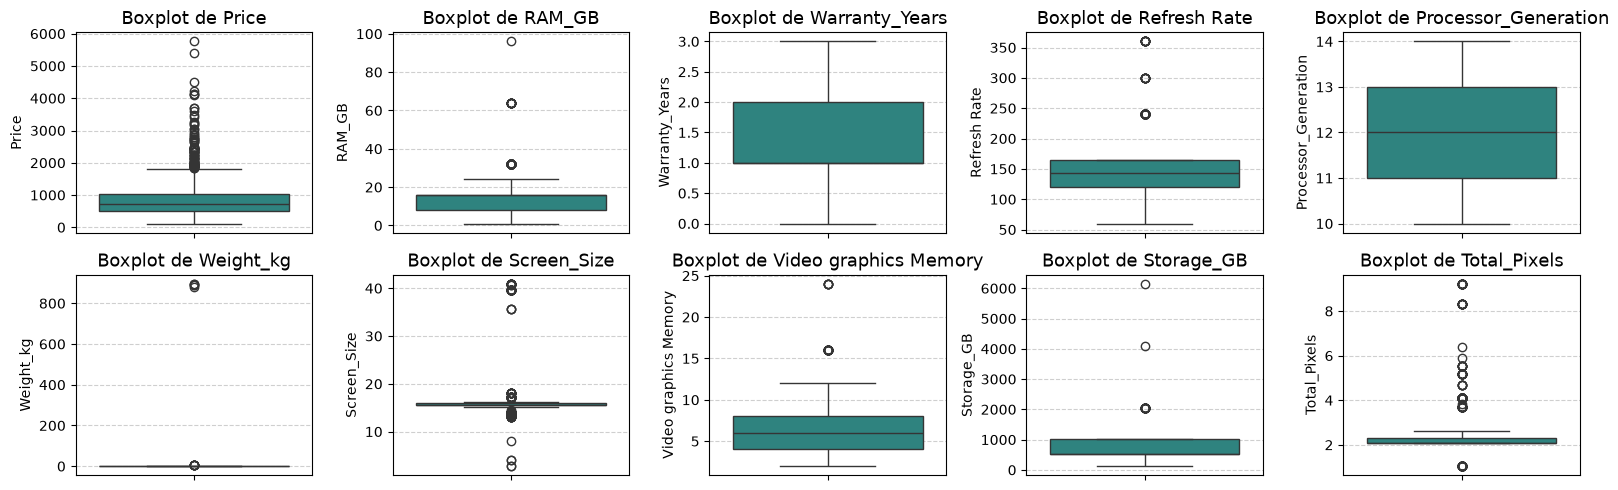

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

#Configuración de la figura(creamos una cuadrícula de subplots)
fig, axes = plt.subplots(nrows = 2, ncols = 5, figsize = (16, 5))    
#Llama a los subplots indicando que tiene 2 filas y 5 columnas
#Llama a fig y axes de esta manera e itera sobre ellos, los subplots
axes = axes.flatten() #Hacemos que la matriz se transforme en unidimensional
#para no tener que hacer bucles con dos coordenadas

#Iteración para pintar cada subplot
for i, col in enumerate(num_cols):    #'enumerate' al pasarle una lista genera un contador numéritco
    sns.boxplot(                      #entonces 'i' valdría 0,1,2... y 'col' valdría 'edad,ingreso...'
        data = df,                    #con 'i' indicas a seaborn en que subplot estás y con 'col' extraes los datos del df
        y = col,
        ax = axes[i],         #Que subplot estoy considerando
        palette = 'viridis',
        orient = 'v',
        legend = False,       #Quita la leyenda repetitiva
    )
    axes[i].set_title(f"Boxplot de {col}", fontsize = 13)
    axes[i].set_ylabel(col)
    axes[i].grid(axis = 'y', linestyle = '--', alpha = 0.6)

plt.tight_layout()
plt.show()

Comenzando por ``Refresh Rate`` observamos que la mayoría de valores se mueven cerca del intervalo habitual de mercado (60-240Hz) observando algún outlier que supera los 300Hz aunque es totalmente factible. Podemos imputar entonces los nulos de esta variable por su mediana, para evitar cualquier pequeña tendencia alcista en la media (inducida por esos valores extremos).

In [125]:
df['Refresh Rate'] = df['Refresh Rate'].fillna(df['Refresh Rate'].median())

Fijándonos en ``Processor_Generation`` vemos que es una variable que se mueve alrededor de sus valores típicos por lo que simplemente imputaremos por la media los valores nulos:

In [126]:
df['Processor_Generation'] = df['Processor_Generation'].fillna(df['Processor_Generation'].mean())

Observando ahora la variable ``Weight_kg`` creo que hay errores con los pesos puesto que no es muy lógico que el peso de un ordenador portátil supere como máximo los 4 kilogramos, vamos a observar esos valores tan exageradamente altos:

In [127]:
df[df['Weight_kg'] > 4.5]

,Brand,Price,RAM_GB,Warranty_Years,Refresh Rate,Processor_Generation,Weight_kg,Screen_Size,Video graphics Memory,Storage_GB,CPU_Class,GPU_Brand,GPU_Tier,Total_Pixels,Has_Webcam,Has_Fingerprint,OS_Type
649,Microsoft,2789.982,32.0,1.0,144.0,12.054598,895.0,NaN,NaN,1024.0,Other,Other,Básica/Integrada,NaN,0,0,Windows
803,Microsoft,1180.782,8.0,1.0,144.0,12.000000,879.0,13.0,NaN,256.0,Gama Baja (i3),Intel,Básica/Integrada,5.5296,0,0,Windows
836,Microsoft,1385.982,16.0,1.0,120.0,11.000000,891.0,13.0,NaN,512.0,Gama Media-Alta (i7),Intel,Básica/Integrada,5.5296,0,0,Windows
837,Microsoft,1313.982,16.0,1.0,120.0,11.000000,891.0,13.0,NaN,256.0,Gama Media-Alta (i7),Intel,Básica/Integrada,5.5296,0,0,Windows
880,Microsoft,2430.000,16.0,1.0,144.0,12.054598,895.0,13.0,NaN,1024.0,Other,Other,Básica/Integrada,NaN,1,0,Windows


De más de 1000 observaciones se observa que hay 5 casos exageradamente extremos (los cuáles pueden ser realmente gramos simplemente habría que convertirlos a kilogramos mediante un cambio de unidad). Eliminaremos estas observaciones pues simplemente introducen ruido a nuestro modelo. 

In [128]:
df.drop(df[df['Weight_kg'] > 4.5].index, inplace=True)

C:\Users\Yoog\AppData\Local\Temp\ipykernel_1268\1834450016.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data = df, y = 'Weight_kg', palette = 'viridis')


<Axes: ylabel='Weight_kg'>

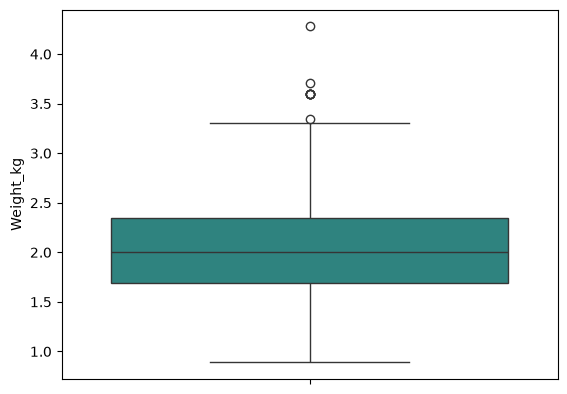

In [129]:
sns.boxplot(data = df, y = 'Weight_kg', palette = 'viridis')

In [130]:
df['Weight_kg'] = df['Weight_kg'].fillna(df['Weight_kg'].mean())

Pasando a ``Screen_Size`` observamos valores extremos muy por encima de los máximos habituales, los cuales rondan las 17.3'' (43.9cm aproximadamente). 

In [131]:
df[df['Screen_Size'] > 17.5]

,Brand,Price,RAM_GB,Warranty_Years,Refresh Rate,Processor_Generation,Weight_kg,Screen_Size,Video graphics Memory,Storage_GB,CPU_Class,GPU_Brand,GPU_Tier,Total_Pixels,Has_Webcam,Has_Fingerprint,OS_Type
0,MSI,5760.000,96.0,2.0,120.0,12.054598,3.60,18.0,24.0,6144.0,Gama Alta (i9),Nvidia,60-50,9.216000,1,0,Windows
7,HP,737.982,16.0,1.0,144.0,13.000000,2.29,39.6,6.0,512.0,Gama Baja (i3),Nvidia,60-50,2.073600,1,0,No OS
26,MSI,1709.982,32.0,2.0,240.0,12.054598,3.10,18.0,8.0,1024.0,Gama Alta (i9),Nvidia,60-50,4.096000,1,0,Windows
28,MSI,4499.982,64.0,2.0,120.0,12.054598,3.60,18.0,24.0,2048.0,Gama Alta (i9),Nvidia,60-50,9.216000,1,0,Windows
30,HP,629.982,8.0,1.0,144.0,13.000000,2.29,39.6,6.0,512.0,Gama Baja (i3),Nvidia,60-50,2.073600,1,0,No OS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,HP,548.982,8.0,1.0,144.0,12.054598,1.74,40.6,NaN,512.0,Other,Intel,Básica/Integrada,2.304000,1,0,No OS
922,HP,611.982,16.0,1.0,144.0,13.000000,1.79,39.6,4.0,1024.0,Gama Baja (i3),Nvidia,60-50,2.073600,1,0,No OS
975,HP,699.984,16.0,1.0,144.0,13.000000,1.38,35.6,NaN,256.0,Gama Baja (i3),Intel,Básica/Integrada,2.073600,1,0,Windows
976,HP,699.984,16.0,1.0,144.0,13.000000,1.79,39.6,NaN,256.0,Gama Baja (i3),Intel,Básica/Integrada,1.049088,1,0,Windows


Entenderemos este error como un fallo de escritura donde estas observaciones se han introducido como centímetros así que haremos una conversión de unidades (centímetros x 0,3937): 

In [133]:
df.loc[df['Screen_Size'] > 20, 'Screen_Size'] = df.loc[df['Screen_Size'] > 20, 'Screen_Size'] / 2.54

Valores por debajo de 13'' es difícil reconvertirlos (aquí se presentan pocos) por lo que eliminaremos el ruido que introducen a la variable. 
Además comprobamos si la media de la variable es coherente para imputar sus nulos.

In [139]:
df = df[df['Screen_Size'] >= 13]
print(df['Screen_Size'].describe())

count    1020.000000
mean       15.458482
std         0.832069
min        13.000000
25%        15.600000
50%        15.600000
75%        15.600000
max        18.000000
Name: Screen_Size, dtype: float64


In [140]:
df['Screen_Size'] = df['Screen_Size'].fillna(df['Screen_Size'].mean())